# Simplified Morphology + Spectroscopy Analysis

This notebook extracts hyperspectral image data from an Agilent IR file, segments particle candidates using thresholding, collapses each particle spectrum with PCA, matches the result against the OS cluster library, and writes the final particle composition results to CSV.

In [62]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from agilent_ir_file import AgilentIRFile
import agilent_to_python as a2p
from calc_pca import cpca
import spec_process as spec_p
import library_OS_fit as lib_OS
from skimage.measure import label, regionprops

DTYPE = np.float32

In [63]:
# Cell 2: Load the Agilent IR file and extract hyperspectral data
filename = r'C:\Users\Stephanie.Wang\Downloads\uog2-q3\uog2-q3.dmt'  # update this path to your file

reader = AgilentIRFile()
reader.read(filename)

wavenumbers = a2p.data_wns(reader).astype(DTYPE)
intensities = reader.intensities.astype(DTYPE)  # shape: (rows, cols, bands)
total_image = reader.total_image.astype(DTYPE)  # integrated absorbance image
metadata = reader.metadata

print('wavenumbers:', wavenumbers.shape)
print('intensities:', intensities.shape)
print('total_image:', total_image.shape)
print('metadata keys:', list(metadata.keys()) if isinstance(metadata, dict) else type(metadata))
print('metadata values:')
for key, value in metadata.items():
    print(f'  {key}: {value}')

# Calculate pixel size and area conversion
pixel_size_microns = metadata.get('fpasize', 64)  # Default to 64 if not found
pixel_area_microns2 = pixel_size_microns ** 2

print(f'\nPixel size: {pixel_size_microns} × {pixel_size_microns} microns')
print(f'Area per pixel: {pixel_area_microns2} μm²')

total_area_mm2 = metadata.get('xpixels', 1344) * metadata.get('ypixels', 1088) * pixel_area_microns2 / 1e6
print(f'Total image area: {total_area_mm2:.1f} mm²')

wavenumbers: (1505,)
intensities: (1088, 1344, 1558)
total_image: (1088, 1344)
metadata keys: ['filename', 'xpixels', 'ypixels', 'xtiles', 'ytiles', 'numpts', 'fpasize', 'firstwavenumber', 'lastwavenumber', 'xlabel', 'ylabel', 'acqdatetime', 'datashape']
metadata values:
  filename: C:\Users\Stephanie.Wang\Downloads\uog2-q3\uog2-q3.dmt
  xpixels: 1344
  ypixels: 1088
  xtiles: 21
  ytiles: 17
  numpts: 1558
  fpasize: 64
  firstwavenumber: 898.6657495498656
  lastwavenumber: 3901.2892947196956
  xlabel: wavenumber (cm^-1)
  ylabel: absorbance
  acqdatetime: 2026-03-11T17:44:19
  datashape: (y, x, wavenumbers)

Pixel size: 64 × 64 microns
Area per pixel: 4096 μm²
Total image area: 5989.5 mm²


In [ ]:
# Add this to your analysis
pixel_area_um2 = 4096  # μm² per pixel
df['area_um2'] = df['pixel_count'] * pixel_area_um2
df['area_mm2'] = df['area_um2'] / 1_000_000

5x mean:           -70.27
Otsu (automatic):  533.23
Li (min entropy):  -65.96
90th percentile:   98.53
mean + 2*std:      344.19


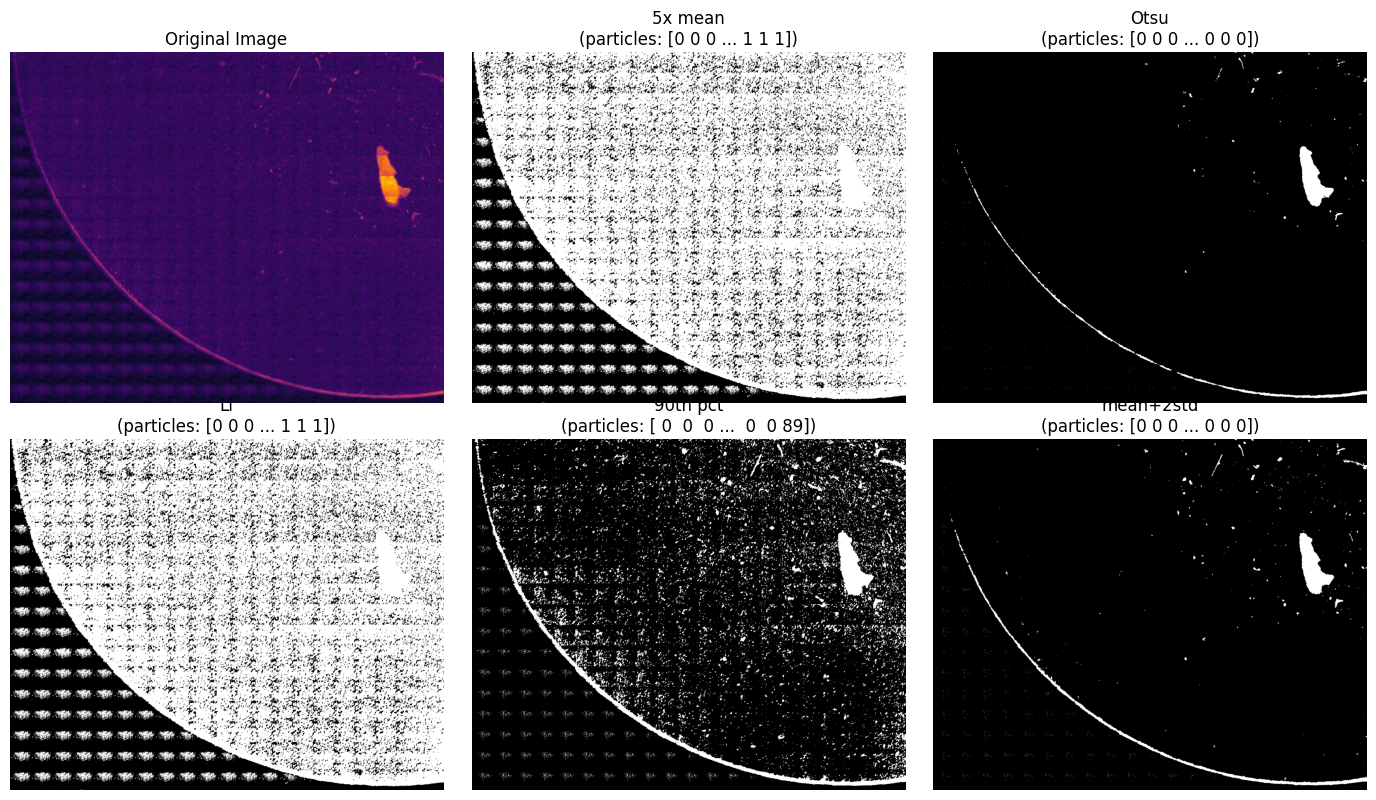


→ Inspect the masks above and choose the best method. Update the threshold below.


In [64]:
# Cell 3a: Compare different thresholding methods
from skimage.filters import threshold_otsu, threshold_li

# Calculate different threshold candidates
thresh_5x_mean = 5 * total_image.mean()
thresh_otsu = threshold_otsu(total_image)
thresh_li = threshold_li(total_image)
thresh_percentile_90 = np.percentile(total_image, 90)
thresh_mean_2std = total_image.mean() + 2 * total_image.std()

print(f'5x mean:           {thresh_5x_mean:.2f}')
print(f'Otsu (automatic):  {thresh_otsu:.2f}')
print(f'Li (min entropy):  {thresh_li:.2f}')
print(f'90th percentile:   {thresh_percentile_90:.2f}')
print(f'mean + 2*std:      {thresh_mean_2std:.2f}')

# Visualize all methods side-by-side
thresholds = {
    '5x mean': thresh_5x_mean,
    'Otsu': thresh_otsu,
    'Li': thresh_li,
    '90th pct': thresh_percentile_90,
    'mean+2std': thresh_mean_2std
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

axes[0].imshow(total_image, cmap='inferno')
axes[0].set_title('Original Image')
axes[0].axis('off')

for idx, (name, thresh) in enumerate(thresholds.items(), start=1):
    mask_test = total_image > thresh
    particle_count = label(mask_test)[1]
    axes[idx].imshow(mask_test, cmap='gray')
    axes[idx].set_title(f'{name}\n(particles: {particle_count})')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Choose the best threshold visually, then use it below
print("\n→ Inspect the masks above and choose the best method. Update the threshold below.")

Using threshold method: Mean + 2*Std = 344.19
Particles found: [0 0 0 ... 0 0 0]


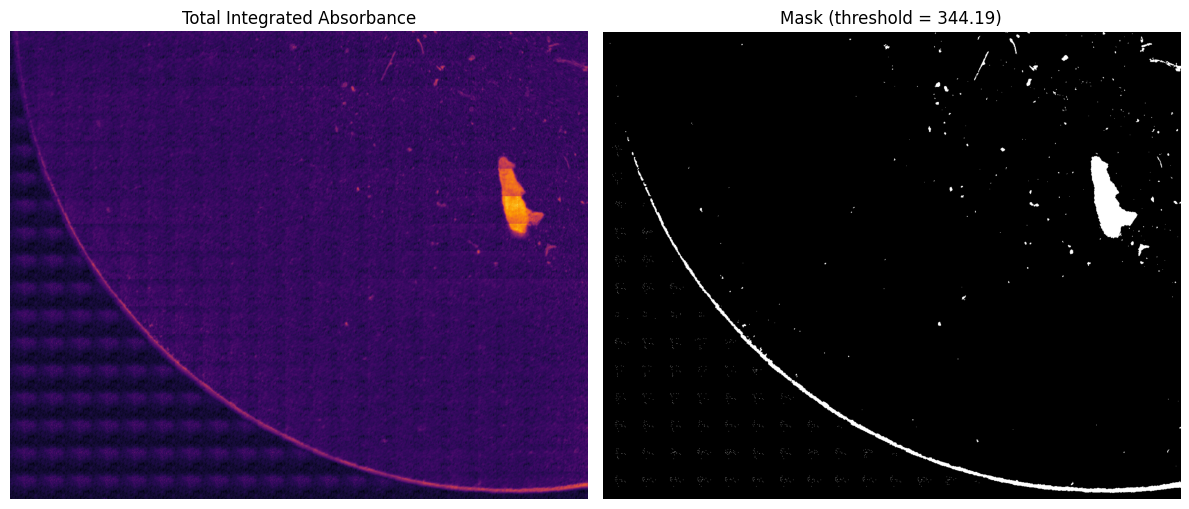

In [65]:
# Cell 3b: Apply chosen threshold
# Update this line based on the visualization above. Options:
# threshold = thresh_5x_mean      # Original heuristic (5x mean)
# threshold = thresh_otsu         # Otsu's method (usually best)
# threshold = thresh_li           # Li's minimum cross-entropy
# threshold = thresh_percentile_90 # Top 10% brightest pixels
# threshold = thresh_mean_2std    # Mean + 2 standard deviations

threshold = thresh_mean_2std  # ← CHANGE THIS if needed after viewing masks above
mask = total_image > threshold

print(f'Using threshold method: Mean + 2*Std = {threshold:.2f}')
print(f'Particles found: {label(mask)[1]}')

# Display result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(total_image, cmap='inferno')
axes[0].set_title('Total Integrated Absorbance')
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Mask (threshold = {threshold:.2f})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [66]:
# Cell 4: Label particles and prepare matching functions
lbls, num_particles = label(mask, return_num=True)
props = regionprops(lbls)
print(f'Found {num_particles} particle candidates')

library_wavenos = lib_OS.get_lib_wns().astype(DTYPE)
library_spectra = pd.read_csv('OS_clusters_derint.csv').values.T.astype(DTYPE)

def match_library(spectrum):
    spectrum = (spectrum - np.mean(spectrum)) / (np.std(spectrum) + 1e-8)
    library_norm = (library_spectra - np.mean(library_spectra, axis=1, keepdims=True)) / (np.std(library_spectra, axis=1, keepdims=True) + 1e-8)
    correlations = np.dot(library_norm, spectrum) / spectrum.shape[0]
    if not np.isfinite(correlations).any():
        return -1, 0.0
    best_ix = int(np.nanargmax(correlations))
    best_pr = float(correlations[best_ix])
    return best_ix, best_pr

def analyze_particle(prop):
    coords = prop.coords
    spectra = []
    for row, col in coords:
        spectra.append(intensities[int(row), int(col)])
    spectra = np.asarray(spectra, dtype=DTYPE)
    if spectra.size == 0 or spectra.shape[1] == 0:
        return {'label': prop.label, 'polymer': 'small particle', 'best_pr': 0.0, 'pixel_count': 0, 'error': 'empty spectrum'}
    if spectra.shape[0] < 5:
        return {'label': prop.label, 'polymer': 'small particle', 'best_pr': 0.0, 'pixel_count': spectra.shape[0]}
    try:
        pca_components = cpca(spectra, range(1))
        if len(pca_components) == 0 or pca_components[0].size == 0:
            raise ValueError('PCA returned no components')
        representative = pca_components[0].astype(DTYPE)
    except Exception as e:
        return {'label': prop.label, 'polymer': 'error', 'best_pr': 0.0, 'pixel_count': spectra.shape[0], 'error': f'PCA failure: {e}'}
    if representative.shape[0] != wavenumbers.shape[0]:
        representative = np.interp(
            wavenumbers,
            np.linspace(wavenumbers[0], wavenumbers[-1], representative.shape[0]),
            representative
        ).astype(DTYPE)
    try:
        processed = spec_p.proc(representative, 5, 2, wavenumbers, library_wavenos)
        if processed.size == 0:
            raise ValueError('processed spectrum is empty')
        best_ix, best_pr = match_library(processed)
    except Exception as e:
        return {'label': prop.label, 'polymer': 'error', 'best_pr': 0.0, 'pixel_count': spectra.shape[0], 'error': f'processing failure: {e}'}
    try:
        polymer_name = lib_OS.catID(best_ix)
    except Exception:
        polymer_name = 'unknown polymer'
        best_pr = 0.0
    if best_pr < 0.3:
        polymer_name = f'{polymer_name} (low confidence)'
    return {'label': prop.label, 'polymer': polymer_name, 'best_pr': best_pr, 'pixel_count': spectra.shape[0]}

Found 1098 particle candidates


In [ ]:
# Cell 5: Analyze all particles and write results to CSV
results = []
for i, prop in enumerate(props, start=1):
    result = analyze_particle(prop)
    results.append(result)
    if i % 50 == 0 or i == len(props):
        print(f'Processed {i}/{len(props)} particles')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('label').reset_index(drop=True)

pixel_size_microns = metadata.get('fpasize', 64)
results_df['area_um2'] = results_df['pixel_count'] * (pixel_size_microns ** 2)
results_df['area_mm2'] = results_df['area_um2'] / 1_000_000

output_path = 'simplified_particle_results.csv'
results_df.to_csv(output_path, index=False)

print(f'Wrote results to {output_path}')
results_df.head(20)

pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
Processed 50/1098 particles
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
Processed 100/1098 particles
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
Processed 150

,label,polymer,best_pr,pixel_count
0,1,small particle,0.000000,1
1,2,polyethylene (low confidence),0.186784,21
2,3,polyethylene,0.497378,34
3,4,small particle,0.000000,1
4,5,polyamide (low confidence),0.199573,29
5,6,silica (low confidence),0.027695,5
6,7,small particle,0.000000,2
7,8,polyethylene,0.481010,46
8,9,small particle,0.000000,1
9,10,small particle,0.000000,2
